##Importing And Loading Data

In [ ]:
import pandas as pd
df = pd.read_csv("/content/customer_data.csv")
df.head(5)

,ID,Name,Age,Gender,Email,City,Salary,Purchase_Amount,Signup_Date,Subscription_Type
0,1,Mrs. Lisa Long,60.0,Female,ortiztina@hotmail.com,Shawnborough,51911.0,958.28,2023-02-23,Premium
1,2,Johnny Harrison,NaN,Other,wwebb@brown-nguyen.com,East Brian,NaN,236.72,2021-10-24,Premium
2,3,Casey Calderon,53.0,Male,shawn84@wallace.org,Anthonyside,109812.0,607.25,2024-06-14,Standard
3,4,Calvin Carter,46.0,Female,nelsonerika@yahoo.com,East Taramouth,40748.0,NaN,2021-10-07,Basic
4,5,Susan Bates,67.0,Female,singletonmichelle@hotmail.com,Clintonmouth,100448.0,696.47,2024-03-16,Standard


In [ ]:
df.shape

(1050, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1050 non-null   int64  
 1   Name               995 non-null    object 
 2   Age                944 non-null    float64
 3   Gender             999 non-null    object 
 4   Email              1006 non-null   object 
 5   City               994 non-null    object 
 6   Salary             933 non-null    float64
 7   Purchase_Amount    954 non-null    float64
 8   Signup_Date        994 non-null    object 
 9   Subscription_Type  1006 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 82.2+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Name,55
Age,106
Gender,51
Email,44
City,56
Salary,117
Purchase_Amount,96
Signup_Date,56
Subscription_Type,44


In [ ]:
df.describe()

,ID,Age,Salary,Purchase_Amount
count,1050.000000,944.000000,933.000000,954.000000
mean,502.380952,43.793432,92168.359057,512.971237
std,288.838378,15.615975,34807.092350,287.858979
min,1.000000,18.000000,30079.000000,11.110000
25%,253.250000,30.000000,62103.000000,271.847500
50%,503.500000,44.000000,92893.000000,526.125000
75%,751.750000,58.000000,122264.000000,767.482500
max,1000.000000,70.000000,149946.000000,999.030000


##Removing Unused column  

In [ ]:
df=df.drop(columns=['Name','Email'])

##Missing values replaced with Median and Mode

In [ ]:
num_cols=['Age','Salary','Purchase_Amount']
for col in num_cols:
  df[col]=df[col].fillna(df[col].median())
cat_cols=['Gender','City','Subscription_Type']
for col in cat_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

df['Signup_Date']=pd.to_datetime(df['Signup_Date'],errors='coerce')
df['Signup_Date']=df['Signup_Date'].fillna(df['Signup_Date'].mode()[0])
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
City,0
Salary,0
Purchase_Amount,0
Signup_Date,0
Subscription_Type,0


##Create Age Groups


In [ ]:
def categorize_age(age):
  if age <25:
    return '18-25'
  elif age<35:
    return '25-34'
  elif age < 45:
      return '35-44'
  elif age < 55:
      return '45-54'
  else:
      return '55+'
df['Age_Group']=df['Age'].apply(categorize_age)


##Create Purchase-to-Salary Ratio

In [ ]:
df['Purchase_to_Salary_Ratio']=(df['Purchase_Amount']/df['Salary']*100).round(2)

In [ ]:
print(df['Purchase_to_Salary_Ratio'])

0       1.85
1       0.25
2       0.55
3       1.29
4       0.69
        ... 
1045    0.52
1046    0.48
1047    0.33
1048    0.38
1049    0.07
Name: Purchase_to_Salary_Ratio, Length: 1050, dtype: float64


##Extract Month and Year from Signup_Date

In [ ]:
df['Signup_Month'] = df['Signup_Date'].dt.month
df['Signup_Year'] = df['Signup_Date'].dt.year


In [ ]:
print(df[['Age', 'Age_Group', 'Purchase_Amount', 'Salary', 'Purchase_to_Salary_Ratio']].head())

    Age Age_Group  Purchase_Amount    Salary  Purchase_to_Salary_Ratio
0  60.0       55+          958.280   51911.0                      1.85
1  44.0     35-44          236.720   92893.0                      0.25
2  53.0     45-54          607.250  109812.0                      0.55
3  46.0     45-54          526.125   40748.0                      1.29
4  67.0       55+          696.470  100448.0                      0.69


##KPIs

In [ ]:
print("="*60)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("="*60)

# ===== REVENUE METRICS =====
print("\n📊 REVENUE METRICS:")
print("-" * 40)
total_revenue = df['Purchase_Amount'].sum()
avg_purchase = df['Purchase_Amount'].mean()
max_purchase = df['Purchase_Amount'].max()
min_purchase = df['Purchase_Amount'].min()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Purchase Value: ${avg_purchase:,.2f}")
print(f"Highest Purchase: ${max_purchase:,.2f}")
print(f"Lowest Purchase: ${min_purchase:,.2f}")

# ===== CUSTOMER METRICS =====
print("\n👥 CUSTOMER METRICS:")
print("-" * 40)
total_customers = len(df)
avg_age = df['Age'].mean()
avg_salary = df['Salary'].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Average Customer Age: {avg_age:.1f} years")
print(f"Average Customer Salary: ${avg_salary:,.2f}")

# ===== REVENUE BY CATEGORY =====
print("\n💰 REVENUE BY SUBSCRIPTION TYPE:")
print("-" * 40)
revenue_by_subscription = df.groupby('Subscription_Type')['Purchase_Amount'].agg(['sum', 'mean', 'count'])
revenue_by_subscription.columns = ['Total_Revenue', 'Avg_Purchase', 'Customer_Count']
print(revenue_by_subscription.sort_values('Total_Revenue', ascending=False))

print("\n🌍 REVENUE BY CITY (Top 10):")
print("-" * 40)
revenue_by_city = df.groupby('City')['Purchase_Amount'].agg(['sum', 'mean', 'count'])
revenue_by_city.columns = ['Total_Revenue', 'Avg_Purchase', 'Customer_Count']
print(revenue_by_city.sort_values('Total_Revenue', ascending=False).head(10))

print("\n⚥ REVENUE BY GENDER:")
print("-" * 40)
revenue_by_gender = df.groupby('Gender')['Purchase_Amount'].agg(['sum', 'mean', 'count'])
revenue_by_gender.columns = ['Total_Revenue', 'Avg_Purchase', 'Customer_Count']
print(revenue_by_gender)

print("\n🎂 REVENUE BY AGE GROUP:")
print("-" * 40)
revenue_by_age = df.groupby('Age_Group')['Purchase_Amount'].agg(['sum', 'mean', 'count'])
revenue_by_age.columns = ['Total_Revenue', 'Avg_Purchase', 'Customer_Count']
print(revenue_by_age.sort_values('Total_Revenue', ascending=False))

KEY PERFORMANCE INDICATORS (KPIs)

📊 REVENUE METRICS:
----------------------------------------
Total Revenue: $539,882.56
Average Purchase Value: $514.17
Highest Purchase: $999.03
Lowest Purchase: $11.11

👥 CUSTOMER METRICS:
----------------------------------------
Total Customers: 1,050
Average Customer Age: 43.8 years
Average Customer Salary: $92,249.10

💰 REVENUE BY SUBSCRIPTION TYPE:
----------------------------------------
                   Total_Revenue  Avg_Purchase  Customer_Count
Subscription_Type                                             
Premium                190742.11    490.339614             389
Basic                  174941.45    522.213284             335
Standard               174199.00    534.352761             326

🌍 REVENUE BY CITY (Top 10):
----------------------------------------
                      Total_Revenue  Avg_Purchase  Customer_Count
City                                                             
West Kevin                 30062.15    501.035833  

##Statistical Analysis & Insights

In [ ]:
print("="*60)
print("STATISTICAL ANALYSIS & INSIGHTS")
print("="*60)

# ===== DESCRIPTIVE STATISTICS =====
print("\n📈 DESCRIPTIVE STATISTICS:")
print("-" * 40)
print(df[['Age', 'Salary', 'Purchase_Amount', 'Purchase_to_Salary_Ratio']].describe())

# ===== CORRELATION ANALYSIS =====
print("\n🔗 CORRELATION ANALYSIS:")
print("-" * 40)
correlation = df[['Age', 'Salary', 'Purchase_Amount']].corr()
print(correlation)

# ===== PURCHASE BEHAVIOR INSIGHTS =====
print("\n💡 PURCHASE BEHAVIOR INSIGHTS:")
print("-" * 40)

# Average spending ratio by subscription type
avg_ratio_by_sub = df.groupby('Subscription_Type')['Purchase_to_Salary_Ratio'].mean().sort_values(ascending=False)
print("\nAverage Purchase-to-Salary Ratio by Subscription:")
print(avg_ratio_by_sub)

# High spenders (top 10%)
high_spender_threshold = df['Purchase_Amount'].quantile(0.90)
high_spenders = df[df['Purchase_Amount'] >= high_spender_threshold]
print(f"\n🔥 High Spenders (Top 10%):")
print(f"Threshold: ${high_spender_threshold:,.2f}")
print(f"Count: {len(high_spenders)}")
print(f"Average Purchase: ${high_spenders['Purchase_Amount'].mean():,.2f}")

# Low spenders (bottom 10%)
low_spender_threshold = df['Purchase_Amount'].quantile(0.10)
low_spenders = df[df['Purchase_Amount'] <= low_spender_threshold]
print(f"\n📉 Low Spenders (Bottom 10%):")
print(f"Threshold: ${low_spender_threshold:,.2f}")
print(f"Count: {len(low_spenders)}")
print(f"Average Purchase: ${low_spenders['Purchase_Amount'].mean():,.2f}")

# ===== OUTLIER DETECTION =====
print("\n⚠️ OUTLIER DETECTION (IQR Method):")
print("-" * 40)

def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['Salary', 'Purchase_Amount']:
    outlier_count, lower, upper = detect_outliers(col)
    print(f"\n{col}:")
    print(f"  Outliers detected: {outlier_count}")
    print(f"  Normal range: ${lower:,.2f} - ${upper:,.2f}")

STATISTICAL ANALYSIS & INSIGHTS

📈 DESCRIPTIVE STATISTICS:
----------------------------------------
               Age         Salary  Purchase_Amount  Purchase_to_Salary_Ratio
count  1050.000000    1050.000000      1050.000000               1050.000000
mean     43.814286   92249.104762       514.173867                  0.660238
std      14.806112   32809.412655       274.397393                  0.506803
min      18.000000   30079.000000        11.110000                  0.010000
25%      32.000000   66366.250000       295.422500                  0.310000
50%      44.000000   92893.000000       526.125000                  0.560000
75%      56.000000  119557.250000       736.112500                  0.850000
max      70.000000  149946.000000       999.030000                  3.060000

🔗 CORRELATION ANALYSIS:
----------------------------------------
                      Age    Salary  Purchase_Amount
Age              1.000000  0.018602        -0.023717
Salary           0.018602  1.000000

##Data Visualizations

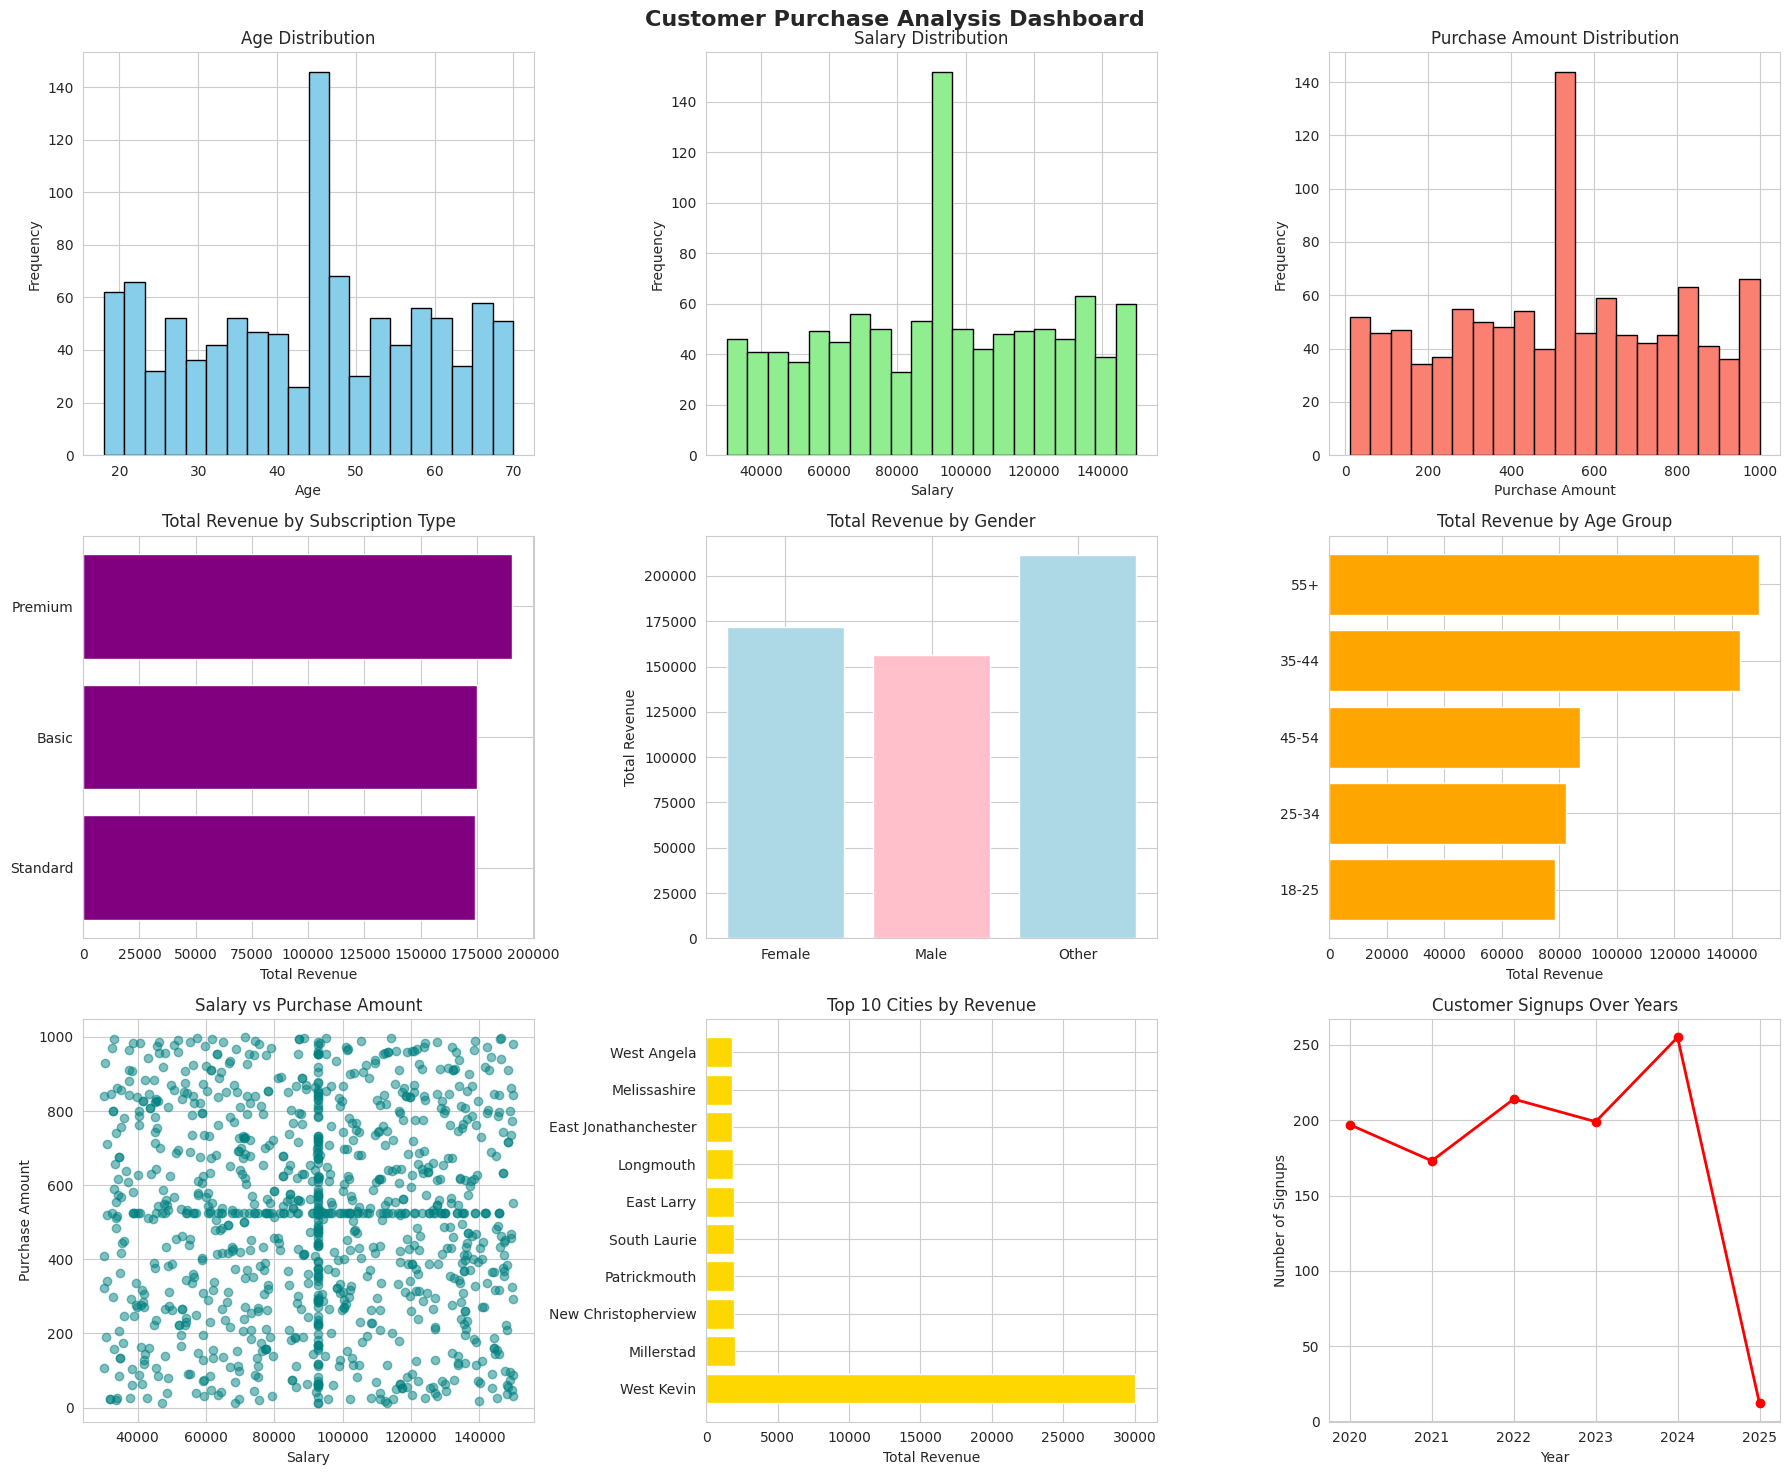

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Customer Purchase Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Age Distribution
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# 2. Salary Distribution
axes[0, 1].hist(df['Salary'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Salary Distribution')
axes[0, 1].set_xlabel('Salary')
axes[0, 1].set_ylabel('Frequency')

# 3. Purchase Amount Distribution
axes[0, 2].hist(df['Purchase_Amount'], bins=20, color='salmon', edgecolor='black')
axes[0, 2].set_title('Purchase Amount Distribution')
axes[0, 2].set_xlabel('Purchase Amount')
axes[0, 2].set_ylabel('Frequency')

# 4. Revenue by Subscription Type
sub_revenue = df.groupby('Subscription_Type')['Purchase_Amount'].sum().sort_values()
axes[1, 0].barh(sub_revenue.index, sub_revenue.values, color='purple')
axes[1, 0].set_title('Total Revenue by Subscription Type')
axes[1, 0].set_xlabel('Total Revenue')

# 5. Revenue by Gender
gender_revenue = df.groupby('Gender')['Purchase_Amount'].sum()
axes[1, 1].bar(gender_revenue.index, gender_revenue.values, color=['lightblue', 'pink'])
axes[1, 1].set_title('Total Revenue by Gender')
axes[1, 1].set_ylabel('Total Revenue')

# 6. Revenue by Age Group
age_revenue = df.groupby('Age_Group')['Purchase_Amount'].sum().sort_values()
axes[1, 2].barh(age_revenue.index, age_revenue.values, color='orange')
axes[1, 2].set_title('Total Revenue by Age Group')
axes[1, 2].set_xlabel('Total Revenue')

# 7. Salary vs Purchase Amount Scatter
axes[2, 0].scatter(df['Salary'], df['Purchase_Amount'], alpha=0.5, color='teal')
axes[2, 0].set_title('Salary vs Purchase Amount')
axes[2, 0].set_xlabel('Salary')
axes[2, 0].set_ylabel('Purchase Amount')

# 8. Top 10 Cities by Revenue
city_revenue = df.groupby('City')['Purchase_Amount'].sum().sort_values(ascending=False).head(10)
axes[2, 1].barh(city_revenue.index, city_revenue.values, color='gold')
axes[2, 1].set_title('Top 10 Cities by Revenue')
axes[2, 1].set_xlabel('Total Revenue')

# 9. Signups Over Time
signup_trend = df.groupby('Signup_Year')['ID'].count()
axes[2, 2].plot(signup_trend.index, signup_trend.values, marker='o', linewidth=2, color='red')
axes[2, 2].set_title('Customer Signups Over Years')
axes[2, 2].set_xlabel('Year')
axes[2, 2].set_ylabel('Number of Signups')
axes[2, 2].grid(True)

plt.tight_layout()
plt.show()

##Heatmaps

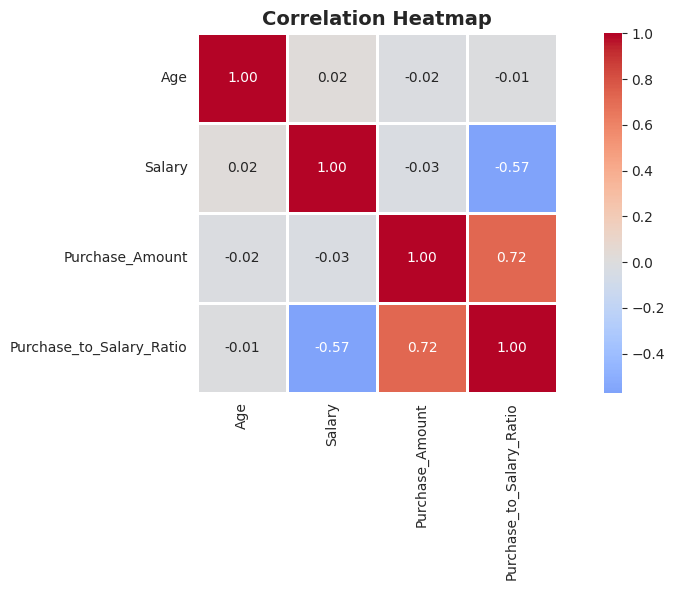

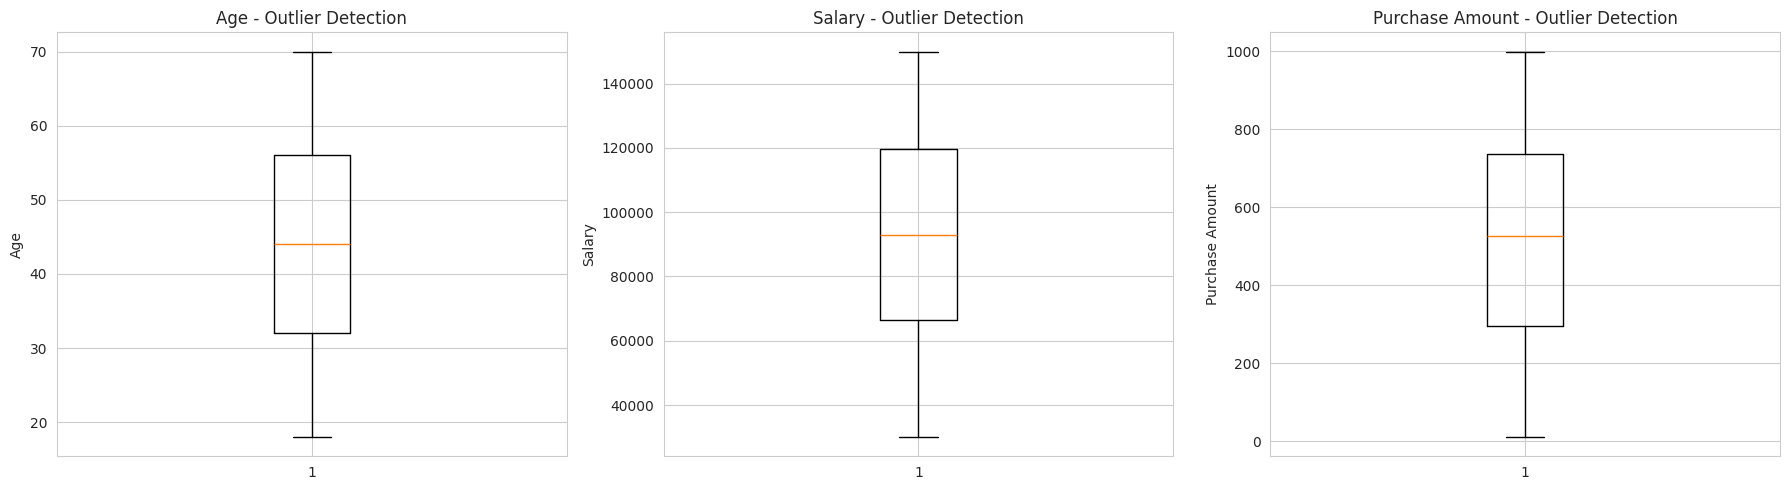

/tmp/ipython-input-4206816582.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Subscription_Type', y='Purchase_Amount', palette='Set2')


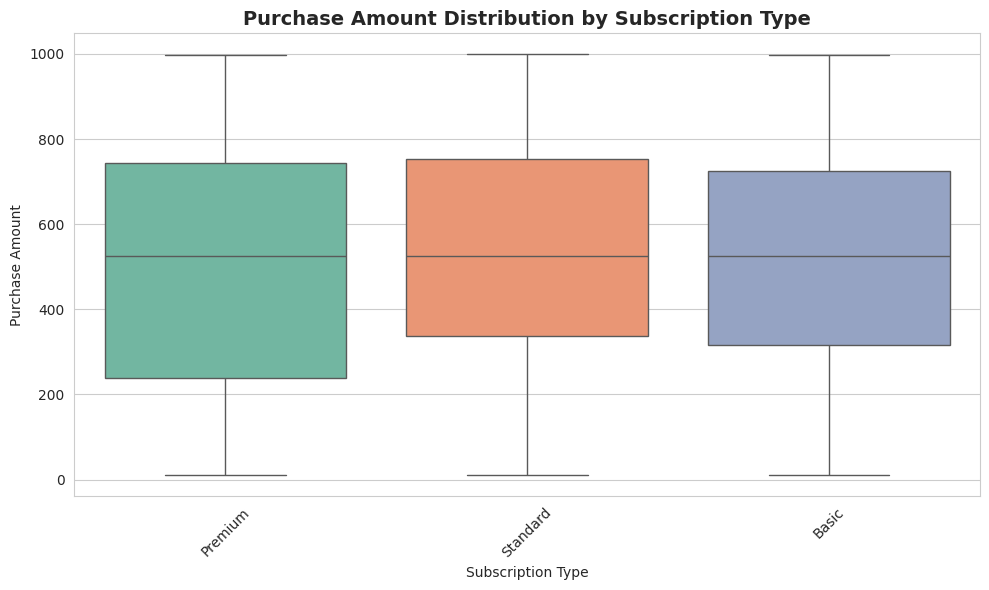

In [ ]:
# CORRELATION HEATMAP
plt.figure(figsize=(10, 6))
correlation_matrix = df[['Age', 'Salary', 'Purchase_Amount', 'Purchase_to_Salary_Ratio']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# BOX PLOTS FOR OUTLIER VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(df['Age'])
axes[0].set_title('Age - Outlier Detection')
axes[0].set_ylabel('Age')

axes[1].boxplot(df['Salary'])
axes[1].set_title('Salary - Outlier Detection')
axes[1].set_ylabel('Salary')

axes[2].boxplot(df['Purchase_Amount'])
axes[2].set_title('Purchase Amount - Outlier Detection')
axes[2].set_ylabel('Purchase Amount')

plt.tight_layout()
plt.show()

# PURCHASE AMOUNT BY SUBSCRIPTION TYPE (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Subscription_Type', y='Purchase_Amount', palette='Set2')
plt.title('Purchase Amount Distribution by Subscription Type', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Type')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=45)
plt.tight_layout()

#Summary

In [ ]:
print("="*70)
print("COMPLETE DATA ANALYSIS SUMMARY REPORT")
print("="*70)

# DATASET OVERVIEW
print("\n1. DATASET OVERVIEW:")
print("-" * 70)
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# DATA QUALITY CHECK
print("\n2. DATA QUALITY:")
print("-" * 70)
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# KEY METRICS SUMMARY
print("\n3. KEY BUSINESS METRICS:")
print("-" * 70)
print(f"Total Revenue: ${df['Purchase_Amount'].sum():,.2f}")
print(f"Average Revenue per Customer: ${df['Purchase_Amount'].mean():,.2f}")
print(f"Median Purchase Amount: ${df['Purchase_Amount'].median():,.2f}")
print(f"Revenue Standard Deviation: ${df['Purchase_Amount'].std():,.2f}")

# CUSTOMER SEGMENTATION
print("\n4. CUSTOMER SEGMENTATION:")
print("-" * 70)

# By Subscription Type
print("\nBy Subscription Type:")
sub_analysis = df.groupby('Subscription_Type').agg({
    'ID': 'count',
    'Purchase_Amount': ['sum', 'mean'],
    'Salary': 'mean'
}).round(2)
sub_analysis.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Purchase', 'Avg_Salary']
print(sub_analysis.sort_values('Total_Revenue', ascending=False))

# By Gender
print("\nBy Gender:")
gender_analysis = df.groupby('Gender').agg({
    'ID': 'count',
    'Purchase_Amount': ['sum', 'mean'],
    'Salary': 'mean'
}).round(2)
gender_analysis.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Purchase', 'Avg_Salary']
print(gender_analysis)

# By Age Group
print("\nBy Age Group:")
age_analysis = df.groupby('Age_Group').agg({
    'ID': 'count',
    'Purchase_Amount': ['sum', 'mean'],
    'Salary': 'mean'
}).round(2)
age_analysis.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Purchase', 'Avg_Salary']
print(age_analysis.sort_values('Total_Revenue', ascending=False))

# TOP PERFORMING CITIES
print("\n5. TOP 10 CITIES BY REVENUE:")
print("-" * 70)
top_cities = df.groupby('City').agg({
    'Purchase_Amount': 'sum',
    'ID': 'count'
}).round(2)
top_cities.columns = ['Total_Revenue', 'Customer_Count']
top_cities['Avg_Revenue_per_Customer'] = (top_cities['Total_Revenue'] / top_cities['Customer_Count']).round(2)
print(top_cities.sort_values('Total_Revenue', ascending=False).head(10))

# CORRELATION INSIGHTS
print("\n6. CORRELATION INSIGHTS:")
print("-" * 70)
corr_matrix = df[['Age', 'Salary', 'Purchase_Amount', 'Purchase_to_Salary_Ratio']].corr()
print(corr_matrix)

print("\nKey Correlations:")
print(f"Salary vs Purchase_Amount: {corr_matrix.loc['Salary', 'Purchase_Amount']:.3f}")
print(f"Age vs Purchase_Amount: {corr_matrix.loc['Age', 'Purchase_Amount']:.3f}")
print(f"Purchase_Amount vs Purchase_to_Salary_Ratio: {corr_matrix.loc['Purchase_Amount', 'Purchase_to_Salary_Ratio']:.3f}")

# STATISTICAL INSIGHTS
print("\n7. STATISTICAL DISTRIBUTION:")
print("-" * 70)
print(df[['Age', 'Salary', 'Purchase_Amount', 'Purchase_to_Salary_Ratio']].describe())

# OUTLIER SUMMARY
print("\n8. OUTLIER DETECTION:")
print("-" * 70)
for col in ['Salary', 'Purchase_Amount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Normal Range: ${lower_bound:,.2f} - ${upper_bound:,.2f}")

print("\n" + "="*70)
print("END OF REPORT")
print("="*70)

COMPLETE DATA ANALYSIS SUMMARY REPORT

1. DATASET OVERVIEW:
----------------------------------------------------------------------
Total Records: 1050
Total Columns: 12
Memory Usage: 287.40 KB

2. DATA QUALITY:
----------------------------------------------------------------------
Missing Values:
ID                          0
Age                         0
Gender                      0
City                        0
Salary                      0
Purchase_Amount             0
Signup_Date                 0
Subscription_Type           0
Age_Group                   0
Purchase_to_Salary_Ratio    0
Signup_Month                0
Signup_Year                 0
dtype: int64

Duplicate Rows: 50

3. KEY BUSINESS METRICS:
----------------------------------------------------------------------
Total Revenue: $539,882.56
Average Revenue per Customer: $514.17
Median Purchase Amount: $526.12
Revenue Standard Deviation: $274.40

4. CUSTOMER SEGMENTATION:
----------------------------------------------------

In [ ]:
# 1. Show me your correlation matrix
print(df[['Age', 'Salary', 'Purchase_Amount', 'Purchase_to_Salary_Ratio']].corr())

# 2. Show me basic statistics
print(df[['Age', 'Salary', 'Purchase_Amount']].describe())

# 3. Show me a few sample rows
print(df.head(10))

                               Age    Salary  Purchase_Amount  \
Age                       1.000000  0.018602        -0.023717   
Salary                    0.018602  1.000000        -0.026525   
Purchase_Amount          -0.023717 -0.026525         1.000000   
Purchase_to_Salary_Ratio -0.009732 -0.570594         0.718536   

                          Purchase_to_Salary_Ratio  
Age                                      -0.009732  
Salary                                   -0.570594  
Purchase_Amount                           0.718536  
Purchase_to_Salary_Ratio                  1.000000  
               Age         Salary  Purchase_Amount
count  1050.000000    1050.000000      1050.000000
mean     43.814286   92249.104762       514.173867
std      14.806112   32809.412655       274.397393
min      18.000000   30079.000000        11.110000
25%      32.000000   66366.250000       295.422500
50%      44.000000   92893.000000       526.125000
75%      56.000000  119557.250000       736.112500
m

In [ ]:
# What actually drives purchases?
print("="*70)
print("WHAT DRIVES PURCHASE BEHAVIOR?")
print("="*70)

# 1. By Subscription Type
print("\n1. PURCHASE BY SUBSCRIPTION TYPE:")
print(df.groupby('Subscription_Type')['Purchase_Amount'].agg(['mean', 'median', 'std', 'count']))

# 2. By City (Top 15)
print("\n2. TOP 15 CITIES BY AVERAGE PURCHASE:")
city_stats = df.groupby('City')['Purchase_Amount'].agg(['mean', 'count'])
print(city_stats[city_stats['count'] >= 3].sort_values('mean', ascending=False).head(15))

# 3. By Gender
print("\n3. PURCHASE BY GENDER:")
print(df.groupby('Gender')['Purchase_Amount'].agg(['mean', 'median', 'count']))

# 4. High vs Low Salary Groups
df['Salary_Group'] = pd.cut(df['Salary'], bins=3, labels=['Low', 'Medium', 'High'])
print("\n4. PURCHASE BY SALARY GROUP:")
print(df.groupby('Salary_Group')['Purchase_Amount'].agg(['mean', 'median', 'count']))

# 5. Year-over-year trends
print("\n5. PURCHASE TRENDS BY SIGNUP YEAR:")
print(df.groupby('Signup_Year')['Purchase_Amount'].agg(['mean', 'median', 'count']))

WHAT DRIVES PURCHASE BEHAVIOR?

1. PURCHASE BY SUBSCRIPTION TYPE:
                         mean   median         std  count
Subscription_Type                                        
Basic              522.213284  526.125  262.316426    335
Premium            490.339614  526.125  290.292339    389
Standard           534.352761  526.125  265.612944    326

2. TOP 15 CITIES BY AVERAGE PURCHASE:
                           mean  count
City                                  
New Christopherview  653.290000      3
Longmouth            612.030000      3
Angelaport           548.835000      3
West Kevin           501.035833     60
South Michael        470.521667      3
Michaelfort          320.266667      3

3. PURCHASE BY GENDER:
              mean   median  count
Gender                            
Female  510.189896  526.125    337
Male    519.346379  526.125    301
Other   513.653653  526.125    412

4. PURCHASE BY SALARY GROUP:
                    mean   median  count
Salary_Group           

/tmp/ipython-input-133666293.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Salary_Group')['Purchase_Amount'].agg(['mean', 'median', 'count']))
